# PeMS 5分钟交通流数据整理与统计分析

本 notebook 分为两部分：
- **Part 1**: 合并数据并保存（只需运行一次）
- **Part 2**: 加载已保存数据进行分析（可反复运行）

---
# Part 1: 数据合并与保存
---

## 1.1 环境配置

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import warnings
warnings.filterwarnings('ignore')

print("库加载完成！")

库加载完成！


## 1.2 配置路径

In [2]:
# 原始数据文件夹
DATA_FOLDER = "/data/yuzhang_fei/PEMS/PEMSD3_2025"  # 修改为你的路径

# 输出目录
OUTPUT_DIR = "../output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 合并后的数据文件路径
MERGED_CSV = os.path.join(DATA_FOLDER,'pems_5min_merged.csv')
MERGED_PARQUET = os.path.join(DATA_FOLDER,'pems_5min_merged.parquet')

# 查看文件列表
txt_files = sorted(glob.glob(os.path.join(DATA_FOLDER, "*.txt")))
print(f"找到 {len(txt_files)} 个数据文件")

找到 363 个数据文件


## 1.3 定义字段

In [3]:
MAX_LANES = 8

# 基础字段
base_columns = [
    'Timestamp', 'Station', 'District', 'Freeway', 'Direction',
    'Lane_Type', 'Station_Length', 'Samples', 'Pct_Observed',
    'Total_Flow', 'Avg_Occupancy', 'Avg_Speed'
]

# 车道字段
lane_columns = []
for i in range(1, MAX_LANES + 1):
    lane_columns.extend([
        f'Lane{i}_Samples', f'Lane{i}_Flow', f'Lane{i}_Avg_Occ',
        f'Lane{i}_Avg_Speed', f'Lane{i}_Observed'
    ])

all_columns = base_columns + lane_columns

# 保留的核心字段（去除元数据冗余）
core_columns = ['Timestamp', 'Station', 'Samples', 'Pct_Observed',
                'Total_Flow', 'Avg_Occupancy', 'Avg_Speed']

print(f"原始字段数: {len(all_columns)}")
print(f"保留字段数: {len(core_columns)}")

原始字段数: 52
保留字段数: 7


## 1.4 合并并保存数据

In [4]:
def merge_and_save(file_list, all_cols, keep_cols, output_csv, output_parquet=None):
    """
    合并所有文件并保存
    """
    dfs = []
    total = len(file_list)
    
    for i, f in enumerate(file_list):
        try:
            df = pd.read_csv(f, header=None, names=all_cols, dtype={'Station': str}, low_memory=False)
            # 只保留核心字段
            df = df[keep_cols]
            dfs.append(df)
        except Exception as e:
            print(f"读取失败 {f}: {e}")
        
        if (i + 1) % 10 == 0:
            print(f"已加载 {i + 1}/{total}")
    
    print("\n正在合并...")
    combined = pd.concat(dfs, ignore_index=True)
    print(f"合并完成: {len(combined):,} 行")
    
    # 转换数据类型
    print("转换数据类型...")
    combined['Timestamp'] = pd.to_datetime(combined['Timestamp'], format='%m/%d/%Y %H:%M:%S')
    for col in ['Samples', 'Pct_Observed', 'Total_Flow', 'Avg_Occupancy', 'Avg_Speed']:
        combined[col] = pd.to_numeric(combined[col], errors='coerce')
    
    # 保存 CSV
    print(f"保存 CSV: {output_csv}")
    combined.to_csv(output_csv, index=False)
    csv_size = os.path.getsize(output_csv) / 1024 / 1024
    print(f"CSV 大小: {csv_size:.2f} MB")
    
    # 保存 Parquet（可选，更高效）
    if output_parquet:
        try:
            print(f"保存 Parquet: {output_parquet}")
            combined.to_parquet(output_parquet, index=False)
            pq_size = os.path.getsize(output_parquet) / 1024 / 1024
            print(f"Parquet 大小: {pq_size:.2f} MB")
        except:
            print("Parquet 保存失败，需要: pip install pyarrow")
    
    print("\n✓ 数据保存完成！")
    return combined

In [5]:
# 执行合并（只需运行一次）
df = merge_and_save(txt_files, all_columns, core_columns, MERGED_CSV, MERGED_PARQUET)

已加载 10/363
已加载 20/363
已加载 30/363
已加载 40/363
已加载 50/363
已加载 60/363
已加载 70/363
已加载 80/363
已加载 90/363
已加载 100/363
已加载 110/363
已加载 120/363
已加载 130/363
已加载 140/363
已加载 150/363
已加载 160/363
已加载 170/363
已加载 180/363
已加载 190/363
已加载 200/363
已加载 210/363
已加载 220/363
已加载 230/363
已加载 240/363
已加载 250/363
已加载 260/363
已加载 270/363
已加载 280/363
已加载 290/363
已加载 300/363
已加载 310/363
已加载 320/363
已加载 330/363
已加载 340/363
已加载 350/363
已加载 360/363

正在合并...
合并完成: 196,416,876 行
转换数据类型...
保存 CSV: /data/yuzhang_fei/PEMS/PEMSD3_2025/pems_5min_merged.csv
CSV 大小: 8748.67 MB
保存 Parquet: /data/yuzhang_fei/PEMS/PEMSD3_2025/pems_5min_merged.parquet
Parquet 保存失败，需要: pip install pyarrow

✓ 数据保存完成！


---
# Part 2: 数据分析
---

**从这里开始，可以直接运行（无需重新合并数据）**

## 2.1 加载已保存的数据

In [6]:
import pandas as pd
import numpy as np
import os
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

OUTPUT_DIR = "../output"
MERGED_CSV = os.path.join(DATA_FOLDER, 'pems_5min_merged.csv')
MERGED_PARQUET = os.path.join(DATA_FOLDER, 'pems_5min_merged.parquet')

In [7]:
# 加载数据（优先使用 Parquet）
if os.path.exists(MERGED_PARQUET):
    print("从 Parquet 加载...")
    df = pd.read_parquet(MERGED_PARQUET)
elif os.path.exists(MERGED_CSV):
    print("从 CSV 加载...")
    df = pd.read_csv(MERGED_CSV, dtype={'Station': str}, parse_dates=['Timestamp'])
else:
    raise FileNotFoundError("请先运行 Part 1 合并数据！")

print(f"数据加载完成: {len(df):,} 行")
print(f"\n字段: {df.columns.tolist()}")
display(df.head())

从 CSV 加载...
数据加载完成: 196,416,876 行

字段: ['Timestamp', 'Station', 'Samples', 'Pct_Observed', 'Total_Flow', 'Avg_Occupancy', 'Avg_Speed']


,Timestamp,Station,Samples,Pct_Observed,Total_Flow,Avg_Occupancy,Avg_Speed
0,2025-01-01,308511,18,100,1.0,0.0004,65.1
1,2025-01-01,308512,17,0,44.0,0.0272,63.7
2,2025-01-01,311831,10,100,0.0,NaN,NaN
3,2025-01-01,311832,10,100,3.0,NaN,NaN
4,2025-01-01,311844,20,100,6.0,NaN,NaN


## 2.2 缺失率分析

In [8]:
def analyze_missing(df):
    missing_stats = pd.DataFrame({
        '缺失数': df.isnull().sum(),
        '缺失率(%)': (df.isnull().sum() / len(df) * 100).round(2),
        '有效数': df.notnull().sum(),
        '有效率(%)': (df.notnull().sum() / len(df) * 100).round(2)
    })
    return missing_stats.sort_values('缺失率(%)', ascending=False)

missing_stats = analyze_missing(df)
print("=" * 50)
print("缺失率统计")
print("=" * 50)
display(missing_stats)

缺失率统计


,缺失数,缺失率(%),有效数,有效率(%)
Avg_Speed,75803227,38.59,120613649,61.41
Avg_Occupancy,74059857,37.71,122357019,62.29
Total_Flow,14385061,7.32,182031815,92.68
Samples,0,0.00,196416876,100.00
Station,0,0.00,196416876,100.00
Timestamp,0,0.00,196416876,100.00
Pct_Observed,0,0.00,196416876,100.00


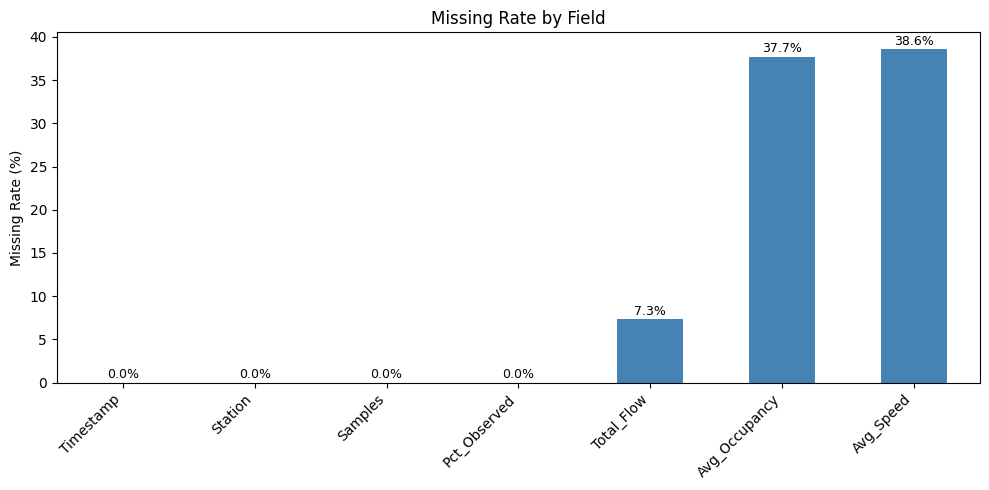

In [9]:
# 缺失率可视化
fig, ax = plt.subplots(figsize=(10, 5))
missing_pct = df.isnull().sum() / len(df) * 100
missing_pct.plot(kind='bar', ax=ax, color='steelblue')
ax.set_ylabel('Missing Rate (%)')
ax.set_title('Missing Rate by Field')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
for i, v in enumerate(missing_pct):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'missing_rate.png'), dpi=150)
plt.show()

## 2.3 基础统计描述

In [10]:
numeric_cols = ['Samples', 'Pct_Observed', 'Total_Flow', 'Avg_Occupancy', 'Avg_Speed']

print("=" * 50)
print("数值字段统计描述")
print("=" * 50)
display(df[numeric_cols].describe().round(2))

数值字段统计描述


,Samples,Pct_Observed,Total_Flow,Avg_Occupancy,Avg_Speed
count,1.964169e+08,1.964169e+08,1.820318e+08,1.223570e+08,1.206136e+08
mean,1.621000e+01,8.204000e+01,8.495000e+01,4.000000e-02,6.428000e+01
std,1.153000e+01,3.780000e+01,1.129800e+02,4.000000e-02,7.140000e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00
25%,1.000000e+01,1.000000e+02,9.000000e+00,1.000000e-02,6.340000e+01
50%,1.000000e+01,1.000000e+02,3.800000e+01,3.000000e-02,6.510000e+01
75%,2.000000e+01,1.000000e+02,1.110000e+02,6.000000e-02,6.760000e+01
max,1.050000e+02,1.000000e+02,1.008000e+03,1.000000e+00,1.000000e+02


In [11]:
# 按站点统计
station_stats = df.groupby('Station').agg({
    'Timestamp': 'count',
    'Total_Flow': ['mean', 'std', 'max'],
    'Avg_Speed': ['mean', 'std'],
    'Avg_Occupancy': ['mean', 'max'],
    'Pct_Observed': 'mean'
}).round(2)

station_stats.columns = ['记录数', '平均流量', '流量标准差', '最大流量',
                          '平均速度', '速度标准差', '平均占有率', '最大占有率', '平均观测率']

print(f"站点数: {len(station_stats)}")
display(station_stats.head(10))

站点数: 1932


,记录数,平均流量,流量标准差,最大流量,平均速度,速度标准差,平均占有率,最大占有率,平均观测率
Station,,,,,,,,,
3001021,104111,81.62,60.63,330.0,62.80,4.01,0.03,0.51,99.36
3001022,104111,46.48,37.72,180.0,NaN,NaN,NaN,NaN,99.36
3001101,104111,12.39,11.05,105.0,NaN,NaN,NaN,NaN,99.36
3001102,104111,52.22,37.85,250.0,66.96,2.18,0.02,0.53,99.36
3001111,104111,46.29,42.50,223.0,67.33,2.13,0.02,0.36,94.88
3001121,104111,47.49,43.33,238.0,67.24,2.21,0.02,0.21,93.37
3002011,93962,1.34,4.59,54.0,NaN,NaN,NaN,NaN,66.67
3002012,93962,14.02,10.94,80.0,NaN,NaN,NaN,NaN,96.74
3002041,93962,58.22,45.34,220.0,61.57,5.37,0.04,1.00,98.60


## 2.4 时间分布分析

In [12]:
# 提取时间特征
df['Date'] = df['Timestamp'].dt.date
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek

daily_counts = df.groupby('Date').size()
print(f"日期范围: {daily_counts.index.min()} ~ {daily_counts.index.max()}")
print(f"总天数: {len(daily_counts)}")
print(f"每日平均记录数: {daily_counts.mean():,.0f}")

日期范围: 2025-01-01 ~ 2025-12-31
总天数: 363
每日平均记录数: 541,093


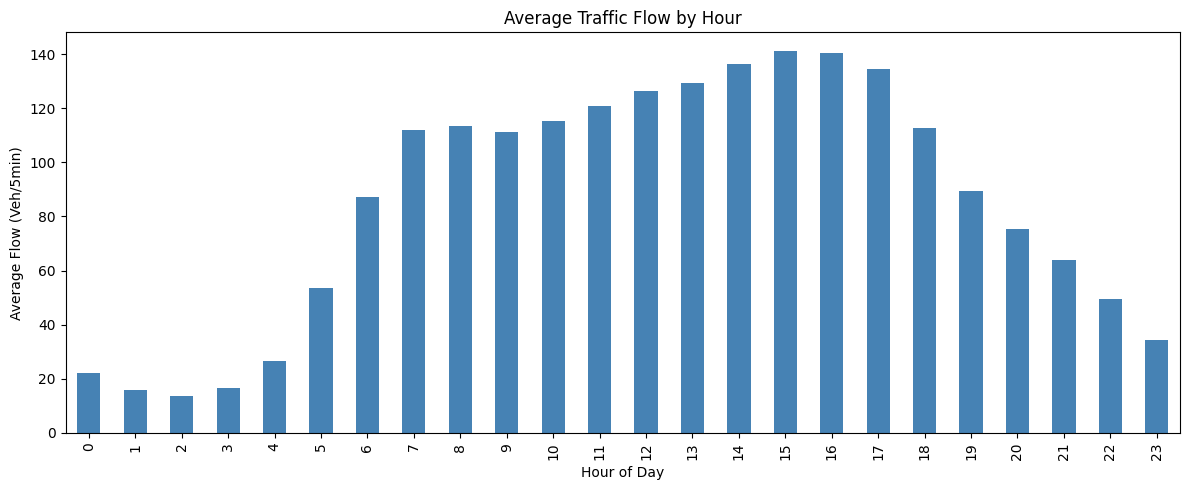

In [13]:
# 按小时统计
hourly_flow = df.groupby('Hour')['Total_Flow'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
hourly_flow.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Flow (Veh/5min)')
ax.set_title('Average Traffic Flow by Hour')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'hourly_flow.png'), dpi=150)
plt.show()

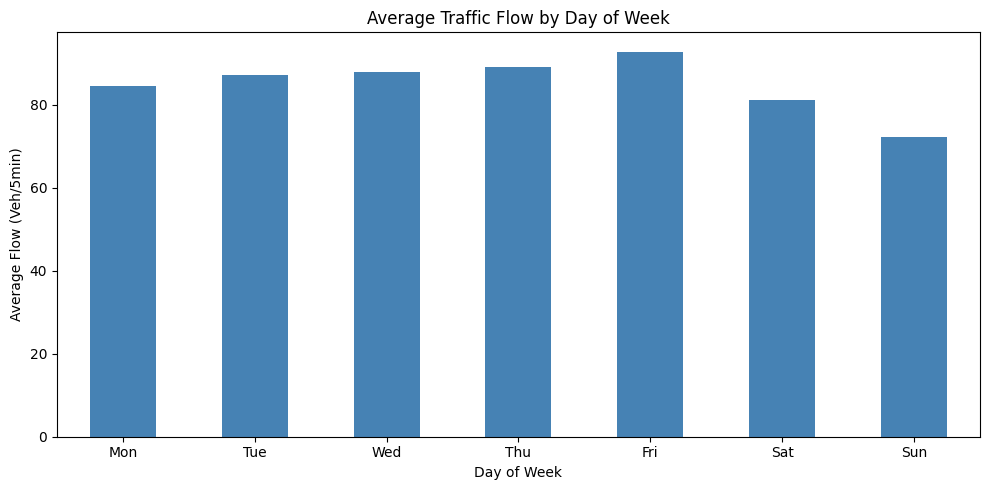

In [14]:
# 按星期统计
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
weekly_flow = df.groupby('DayOfWeek')['Total_Flow'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
weekly_flow.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xticklabels(day_names, rotation=0)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Flow (Veh/5min)')
ax.set_title('Average Traffic Flow by Day of Week')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'weekly_flow.png'), dpi=150)
plt.show()

## 2.5 数据质量分析

In [15]:
# 观测率分布
print("=" * 50)
print("观测率 (Pct_Observed) 分布")
print("=" * 50)

obs_bins = [0, 25, 50, 75, 100]
obs_labels = ['0-25%', '25-50%', '50-75%', '75-100%']
df['Obs_Bin'] = pd.cut(df['Pct_Observed'], bins=obs_bins, labels=obs_labels, include_lowest=True)

obs_dist = df['Obs_Bin'].value_counts().sort_index()
obs_pct = (obs_dist / len(df) * 100).round(2)
print(pd.DataFrame({'数量': obs_dist, '占比(%)': obs_pct}))

观测率 (Pct_Observed) 分布
                数量  占比(%)
Obs_Bin                  
0-25%     33861361  17.24
25-50%     1540042   0.78
50-75%     2059535   1.05
75-100%  158955938  80.93


In [16]:
# 零值分析
print("=" * 50)
print("零值分析")
print("=" * 50)

zero_stats = pd.DataFrame({
    '零值数': (df[numeric_cols] == 0).sum(),
    '零值率(%)': ((df[numeric_cols] == 0).sum() / len(df) * 100).round(2)
})
display(zero_stats)

零值分析


,零值数,零值率(%)
Samples,21348938,10.87
Pct_Observed,33613963,17.11
Total_Flow,13943474,7.10
Avg_Occupancy,4312094,2.20
Avg_Speed,0,0.00


In [17]:
# 异常值检测
def detect_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum(), lower, upper

print("=" * 50)
print("异常值检测 (IQR)")
print("=" * 50)

for col in ['Total_Flow', 'Avg_Speed', 'Avg_Occupancy']:
    n_outliers, lower, upper = detect_outliers_iqr(df[col].dropna())
    pct = n_outliers / df[col].notna().sum() * 100
    print(f"{col}: {n_outliers:,} 异常值 ({pct:.2f}%), 范围: [{lower:.2f}, {upper:.2f}]")

异常值检测 (IQR)
Total_Flow: 16,861,755 异常值 (9.26%), 范围: [-144.00, 264.00]
Avg_Speed: 11,251,130 异常值 (9.33%), 范围: [57.10, 73.90]
Avg_Occupancy: 3,106,293 异常值 (2.54%), 范围: [-0.06, 0.13]


## 2.6 数据分布可视化

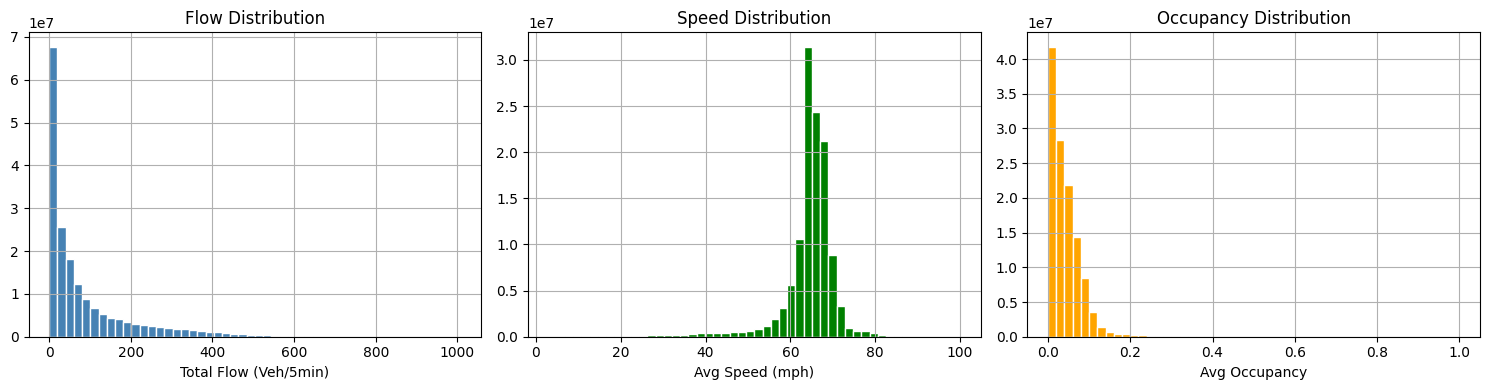

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['Total_Flow'].dropna().hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Total Flow (Veh/5min)')
axes[0].set_title('Flow Distribution')

df['Avg_Speed'].dropna().hist(bins=50, ax=axes[1], color='green', edgecolor='white')
axes[1].set_xlabel('Avg Speed (mph)')
axes[1].set_title('Speed Distribution')

df['Avg_Occupancy'].dropna().hist(bins=50, ax=axes[2], color='orange', edgecolor='white')
axes[2].set_xlabel('Avg Occupancy')
axes[2].set_title('Occupancy Distribution')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distributions.png'), dpi=150)
plt.show()

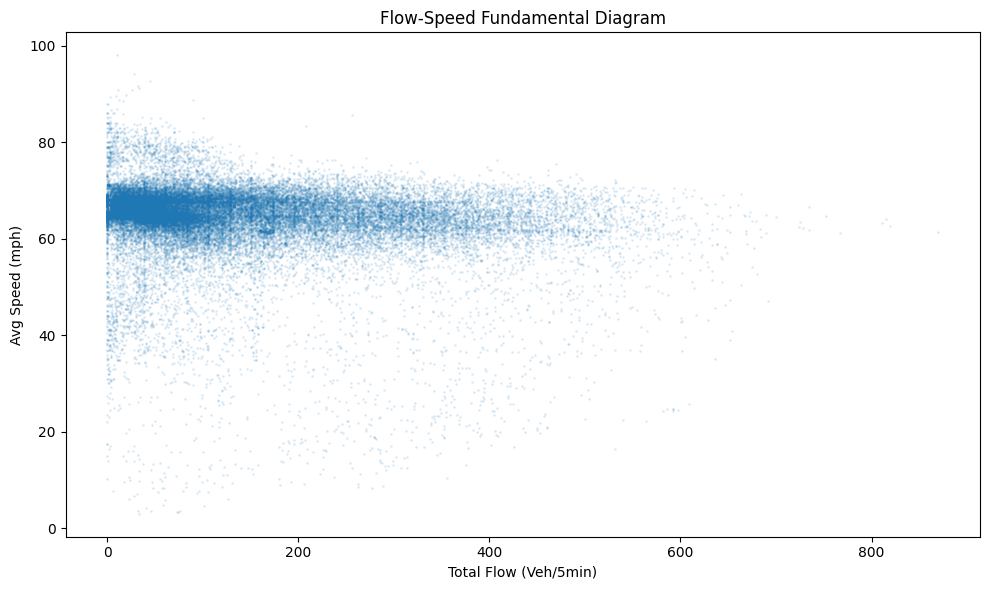

In [19]:
# 流量-速度基本图
sample = df.dropna(subset=['Total_Flow', 'Avg_Speed']).sample(min(50000, len(df)))

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(sample['Total_Flow'], sample['Avg_Speed'], alpha=0.1, s=1)
ax.set_xlabel('Total Flow (Veh/5min)')
ax.set_ylabel('Avg Speed (mph)')
ax.set_title('Flow-Speed Fundamental Diagram')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'flow_speed_diagram.png'), dpi=150)
plt.show()

## 2.7 生成统计报告

In [20]:
report = f"""
{'='*60}
PeMS 5分钟交通流数据统计报告
{'='*60}

【数据概况】
- 总记录数: {len(df):,}
- 站点数: {df['Station'].nunique()}
- 日期范围: {df['Date'].min()} ~ {df['Date'].max()}
- 总天数: {df['Date'].nunique()}

【缺失率统计】
{missing_stats.to_string()}

【核心指标统计】
{df[numeric_cols].describe().round(2).to_string()}

【观测率分布】
{pd.DataFrame({'数量': obs_dist, '占比(%)': obs_pct}).to_string()}

【零值统计】
{zero_stats.to_string()}

{'='*60}
报告生成时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*60}
"""

print(report)

with open(os.path.join(OUTPUT_DIR, 'statistics_report.txt'), 'w') as f:
    f.write(report)
print(f"报告已保存: {OUTPUT_DIR}/statistics_report.txt")


PeMS 5分钟交通流数据统计报告

【数据概况】
- 总记录数: 196,416,876
- 站点数: 1932
- 日期范围: 2025-01-01 ~ 2025-12-31
- 总天数: 363

【缺失率统计】
                    缺失数  缺失率(%)        有效数  有效率(%)
Avg_Speed      75803227   38.59  120613649   61.41
Avg_Occupancy  74059857   37.71  122357019   62.29
Total_Flow     14385061    7.32  182031815   92.68
Samples               0    0.00  196416876  100.00
Station               0    0.00  196416876  100.00
Timestamp             0    0.00  196416876  100.00
Pct_Observed          0    0.00  196416876  100.00

【核心指标统计】
            Samples  Pct_Observed    Total_Flow  Avg_Occupancy     Avg_Speed
count  1.964169e+08  1.964169e+08  1.820318e+08   1.223570e+08  1.206136e+08
mean   1.621000e+01  8.204000e+01  8.495000e+01   4.000000e-02  6.428000e+01
std    1.153000e+01  3.780000e+01  1.129800e+02   4.000000e-02  7.140000e+00
min    0.000000e+00  0.000000e+00  0.000000e+00   0.000000e+00  3.000000e+00
25%    1.000000e+01  1.000000e+02  9.000000e+00   1.000000e-02  6.340000e+01
50%    1.

---
## 使用说明

### 工作流程

```
第一次使用:
    运行 Part 1 (1.1 ~ 1.4) → 合并数据并保存
    运行 Part 2 (2.1 ~ 2.7) → 分析数据

后续使用:
    直接运行 Part 2 (2.1 ~ 2.7) → 加载已保存数据进行分析
```

### 输出文件

| 文件 | 说明 |
|------|------|
| `pems_5min_merged.csv` | 合并后的数据 (CSV) |
| `pems_5min_merged.parquet` | 合并后的数据 (Parquet，更高效) |
| `statistics_report.txt` | 统计报告 |
| `*.png` | 可视化图表 |